In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('insurance_company.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Training set size: {train_df.shape}")
print(f"Testing set size: {test_df.shape}")

Training set size: (1070, 7)
Testing set size: (268, 7)


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   str    
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   str    
 5   region    1070 non-null   str    
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 66.9 KB


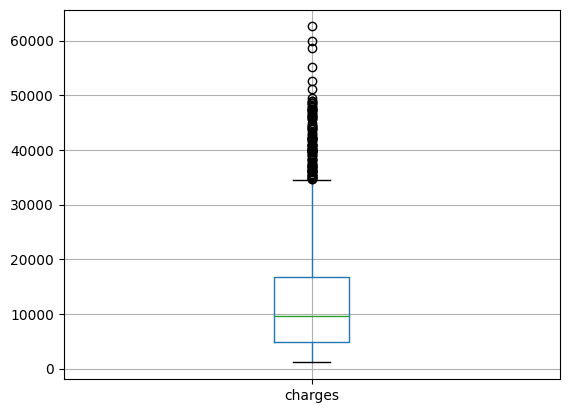

      age     sex     bmi  children smoker     region      charges
947    37    male  34.200         1    yes  northeast  39047.28500
1207   36    male  33.400         2    yes  southwest  38415.47400
1240   52    male  41.800         2    yes  southeast  47269.85400
377    24    male  40.150         0    yes  southeast  38126.24650
322    34    male  30.800         0    yes  southwest  35491.64000
...   ...     ...     ...       ...    ...        ...          ...
34     28    male  36.400         1    yes  southwest  51194.55914
856    48  female  33.110         0    yes  southeast  40974.16490
252    54    male  34.210         2    yes  southeast  44260.74990
330    61  female  36.385         1    yes  northeast  48517.56315
860    37  female  47.600         2    yes  southwest  46113.51100

[111 rows x 7 columns]


In [7]:
train_df.boxplot(column='charges')
plt.show()
def find_outlier(df, dataColumn):
    Q1 = df[dataColumn].quantile(0.25)
    Q3 = df[dataColumn].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[dataColumn] < lower_bound) | (df[dataColumn] > upper_bound)]
    print(outliers)
    return df[(df[dataColumn] >= lower_bound) & (df[dataColumn] <= upper_bound)]

train_df = find_outlier(train_df, 'charges')

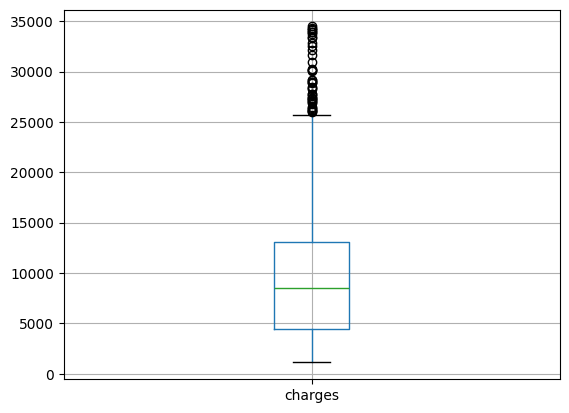

In [8]:
train_df.boxplot(column='charges')
plt.show()

In [9]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 959 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       959 non-null    int64  
 1   sex       959 non-null    str    
 2   bmi       959 non-null    float64
 3   children  959 non-null    int64  
 4   smoker    959 non-null    str    
 5   region    959 non-null    str    
 6   charges   959 non-null    float64
dtypes: float64(2), int64(2), str(3)
memory usage: 59.9 KB


In [10]:
X_train = train_df.drop('charges', axis=1)
y_train = train_df['charges']

X_test = test_df.drop('charges', axis=1)
y_test = test_df['charges']
print('X_train shape = ', X_train.shape, 'y_train.shape = ', y_train.shape)
print('X_test shape =', X_test.shape, 'y_test.shape = ', y_test.shape)

X_train shape =  (959, 6) y_train.shape =  (959,)
X_test shape = (268, 6) y_test.shape =  (268,)


In [11]:
X_train = pd.get_dummies(X_train, columns=['sex', 'smoker', 'region'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['sex', 'smoker', 'region'], dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [12]:
X_train.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,46,19.95,2,1,0,1,0,0,1,0,0
1285,47,24.32,0,1,0,1,0,1,0,0,0
1142,52,24.86,0,1,0,1,0,0,0,1,0
969,39,34.32,5,1,0,1,0,0,0,1,0
486,54,21.47,3,1,0,1,0,0,1,0,0


In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2 = model.score(X_test, y_test)

In [15]:
print ('MSE Train: ', mse_train)
print ('MSE Test: ', mse_test)
print ('R2: ', r2)

MSE Train:  20956829.473109074
MSE Test:  55943790.13548802
R2:  0.6396505813739777


In [16]:
poly = PolynomialFeatures(degree=5, interaction_only=False)
X_poly = poly.fit_transform(X_train)
# scale data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_poly)
# Fit model:
model = LinearRegression()
model.fit(X_scaled, y_train)
print('X Shape: ' , X_scaled.shape)
print('X_poly.shape: ', X_poly.shape)

X Shape:  (959, 4368)
X_poly.shape:  (959, 4368)


In [17]:
lin = LinearRegression()
lin.fit(X_poly, y_train)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print ('MSE Train: ', mse_train)
print ('MSE Test: ', mse_test)
print('R^2 Score: ',lin.score(X_poly, y_train))

MSE Train:  20956829.473109074
MSE Test:  55943790.13548802
R^2 Score:  0.7602145426889372


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print ('MSE Train: ', mse_train)
print ('MSE Test: ', mse_test)
print('R^2 Score: ', model.score(X_test, y_test))

MSE Train:  3220761.5033535883
MSE Test:  30834220.2096909
R^2 Score:  0.8013882631219774
